In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv('creditcard.csv')

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.isnull().any()

Time      False
V1        False
V2        False
V3        False
V4        False
V5        False
V6        False
V7        False
V8        False
V9        False
V10       False
V11       False
V12       False
V13       False
V14       False
V15       False
V16       False
V17       False
V18       False
V19       False
V20       False
V21       False
V22       False
V23       False
V24       False
V25       False
V26       False
V27       False
V28       False
Amount    False
Class     False
dtype: bool

In [10]:
fraud_counts = df['Class'].value_counts()[1]
non_fraud_counts = df['Class'].value_counts()[0]
print(f"Percentage of Fraud: {fraud_counts/(fraud_counts + non_fraud_counts) * 100:.2f}")
print(f"Percentage of Non-Fraud: {non_fraud_counts/(fraud_counts + non_fraud_counts) * 100:.2f}")

Percentage of Fraud: 0.17
Percentage of Non-Fraud: 99.83


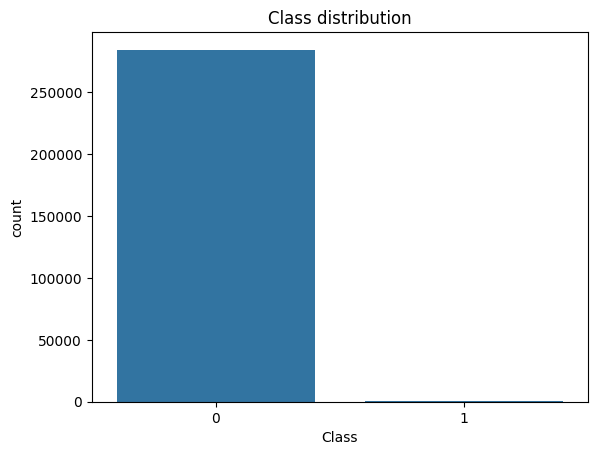

In [11]:
sns.countplot(x='Class', data =df)

plt.title("Class distribution")
plt.show()

In [12]:
#The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of total transactions. This imbalance may bias machine learning models toward predicting non-fraudulent transactions.

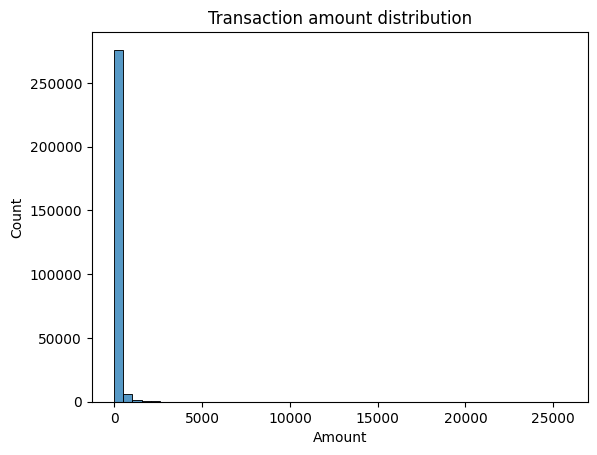

In [13]:
sns.histplot(df['Amount'], bins=50)

plt.title("Transaction amount distribution")
plt.show()

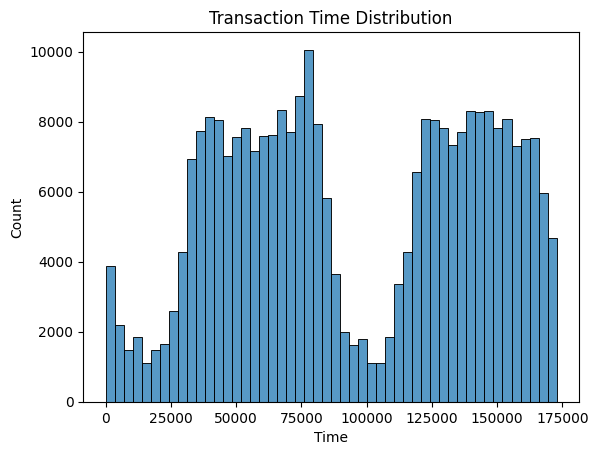

In [14]:
sns.histplot(df['Time'], bins=50)

plt.title('Transaction Time Distribution')
plt.show()

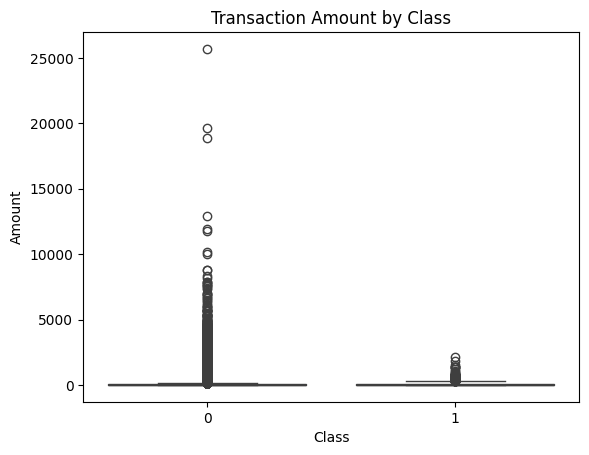

In [15]:
sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.show()

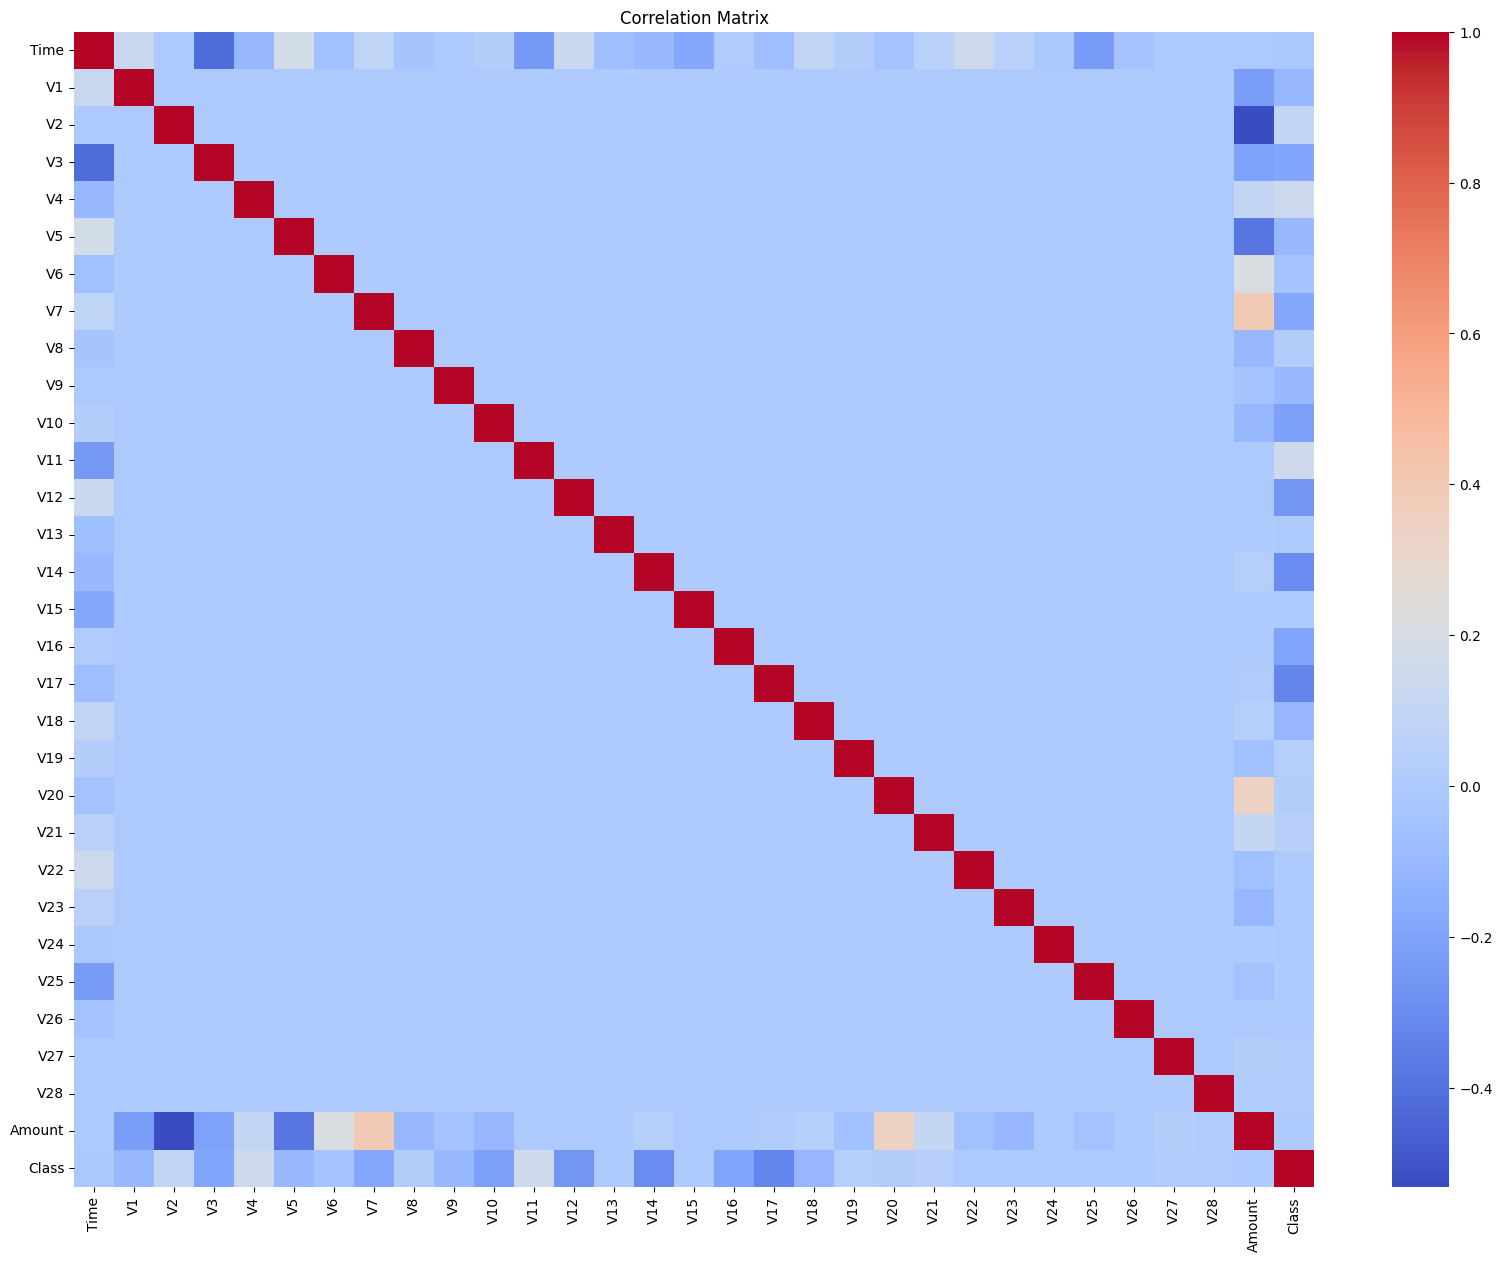

In [16]:
plt.figure(figsize=(20,15))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

Key Findings
- Dataset is extremely imbalanced
- Fraudulent transactions represent less than 1%
- Transaction amounts are heavily skewed
- Certain PCA features show strong correlation with fraud
- Scaling will likely improve model performance
- Imbalance handling techniques may be necessary

In [17]:
X = df.drop('Class', axis=1)
y = df['Class']

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [20]:
df.drop(['Time','Amount'], axis=1, inplace=True)

In [21]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


The Time and Amount features were standardised using StandardScaler to ensure all features operated on a similar scale, improving machine learning model performance.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Now I'm going to test compare:
    No imbalance handling, Hypothesis: High accuracy, low recall
    Class weights, Hypothesis: Lower accuracy, higher recall
    Undersampling, Hypothesis: Balanced performance in general

In [23]:
X = df.drop('Class', axis=1)
y = df['Class']

In [24]:
baseline_model = LogisticRegression(max_iter=100000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9992
Precision: 0.8228
Recall: 0.6633
F1 Score: 0.7345


In [26]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.66      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



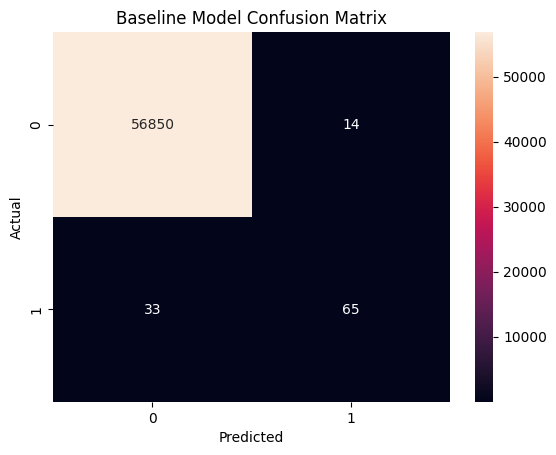

In [27]:
cm = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


The baseline Logistic Regression model achieved very high accuracy due to the dataset imbalance. However, recall for fraudulent transactions was relatively low, meaning many fraud cases were missed. This demonstrates that accuracy alone is not an effective evaluation metric for fraud detection problems.

In [28]:
weighted_model = LogisticRegression(
    class_weight='balanced',
    max_iter = 100000
)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred_weighted)
precision = precision_score(y_test, y_pred_weighted)
recall = recall_score(y_test, y_pred_weighted)
f1 = f1_score(y_test, y_pred_weighted)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9754
Precision: 0.0608
Recall: 0.9184
F1 Score: 0.1140


In [30]:
print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



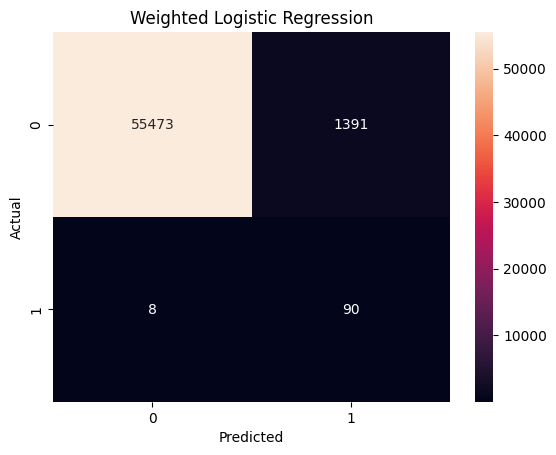

In [31]:
cm = confusion_matrix(y_test, y_pred_weighted)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Weighted Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Although the weighted model achieved slightly lower accuracy, it significantly improved recall, detecting a much larger proportion of fraudulent transactions. This demonstrates the importance of handling class imbalance in fraud detection tasks.

In [32]:
train_data = X_train.copy()

train_data['Class'] = y_train

In [33]:
fraud_train = train_data[train_data['Class'] == 1]

normal_train = train_data[train_data['Class'] == 0]

In [34]:
normal_sample = normal_train.sample(
    n=len(fraud_train),
    random_state=42
)

In [35]:
undersampled_data = pd.concat([
    fraud_train,
    normal_train
])

undersampled_data = undersampled_data.sample(
    frac=1,
    random_state=42
)

In [36]:
X_train_under = undersampled_data.drop('Class', axis=1)

y_train_under = undersampled_data['Class']

In [37]:
undersample_model = LogisticRegression(max_iter=100000)

undersample_model.fit(
    X_train_under,
    y_train_under
)
y_pred_under = undersample_model.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred_under)
precision = precision_score(y_test, y_pred_under)
recall = recall_score(y_test, y_pred_under)
f1 = f1_score(y_test, y_pred_under)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9991
Precision: 0.8101
Recall: 0.6531
F1 Score: 0.7232


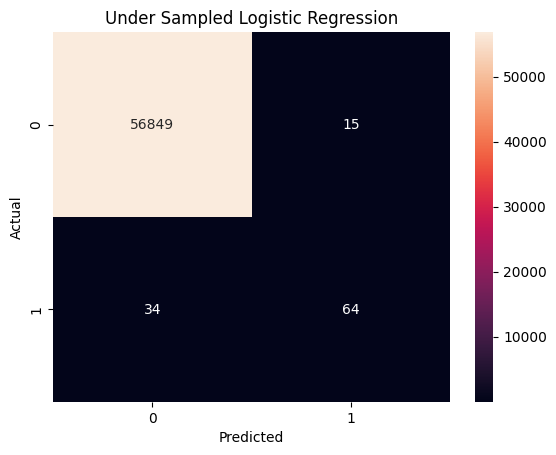

In [39]:
cm = confusion_matrix(y_test, y_pred_under)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Under Sampled Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The original Logistic Regression model achieved the best balance between precision and recall. While class weighting significantly improved recall, it produced excessive false positives, reducing precision dramatically. Undersampling provided little improvement, likely due to information loss from removing legitimate transactions.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier (
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
RFC_y_pred_baseline = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, RFC_y_pred_baseline)
precision = precision_score(y_test, RFC_y_pred_baseline)
recall = recall_score(y_test, RFC_y_pred_baseline)
f1 = f1_score(y_test, RFC_y_pred_baseline)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9996
Precision: 0.9412
Recall: 0.8163
F1 Score: 0.8743


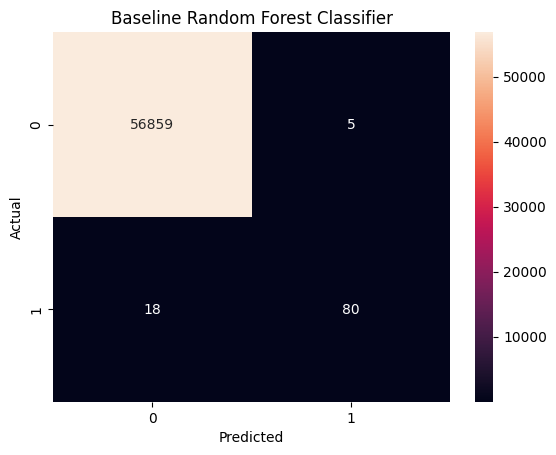

In [42]:
cm = confusion_matrix(y_test, RFC_y_pred_baseline)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Baseline Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
rf_weighted = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
rf_weighted.fit(X_train, y_train)
RFC_y_pred_weighted = rf_weighted.predict(X_test)

In [44]:
accuracy = accuracy_score(y_test, RFC_y_pred_weighted)
precision = precision_score(y_test, RFC_y_pred_weighted)
recall = recall_score(y_test, RFC_y_pred_weighted)
f1 = f1_score(y_test, RFC_y_pred_weighted)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9995
Precision: 0.9605
Recall: 0.7449
F1 Score: 0.8391


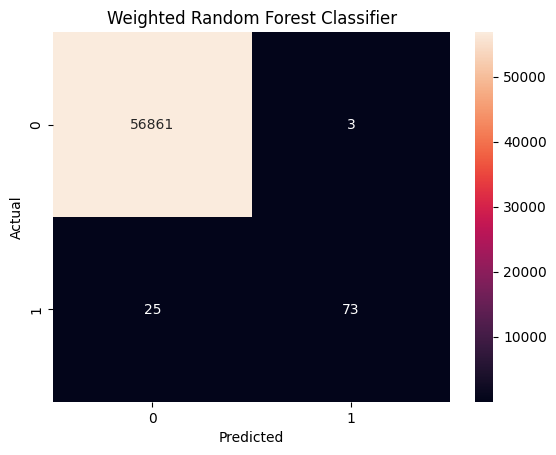

In [45]:
cm = confusion_matrix(y_test, RFC_y_pred_weighted)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Weighted Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()